#### Color Spaces

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

Text(0.5, 1.0, 'Red Channel')

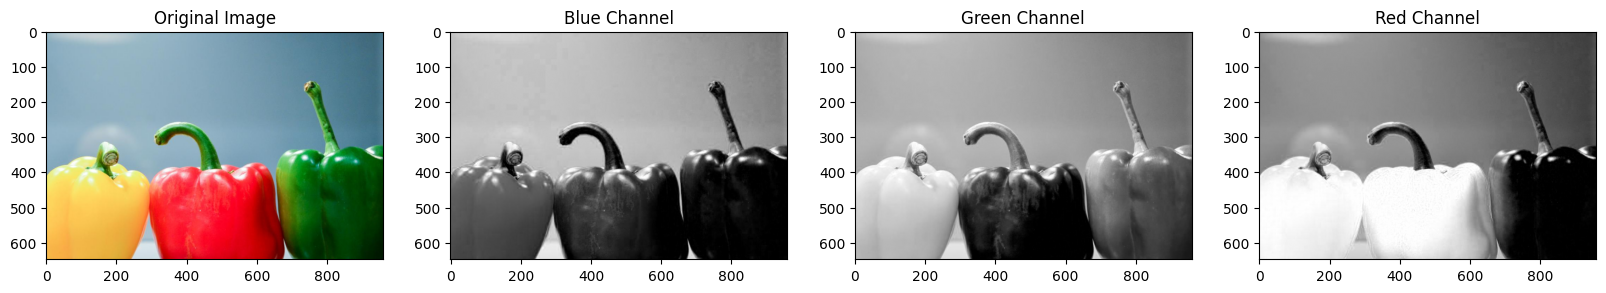

In [3]:
image = cv2.imread('data/images/capsicum.jpg', cv2.IMREAD_COLOR)
plt.figure(figsize=(20, 20))
plt.subplot(141);plt.imshow(image[...,::-1]);plt.title("Original Image")
plt.subplot(142);plt.imshow(image[...,0], cmap="gray");plt.title("Blue Channel")
plt.subplot(143);plt.imshow(image[...,1], cmap="gray");plt.title("Green Channel")
plt.subplot(144);plt.imshow(image[...,2], cmap="gray");plt.title("Red Channel")

#### HSV Color Space (Hue, Saturation, Value)

In [4]:
hsvImage = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

Text(0.5, 1.0, 'Value')

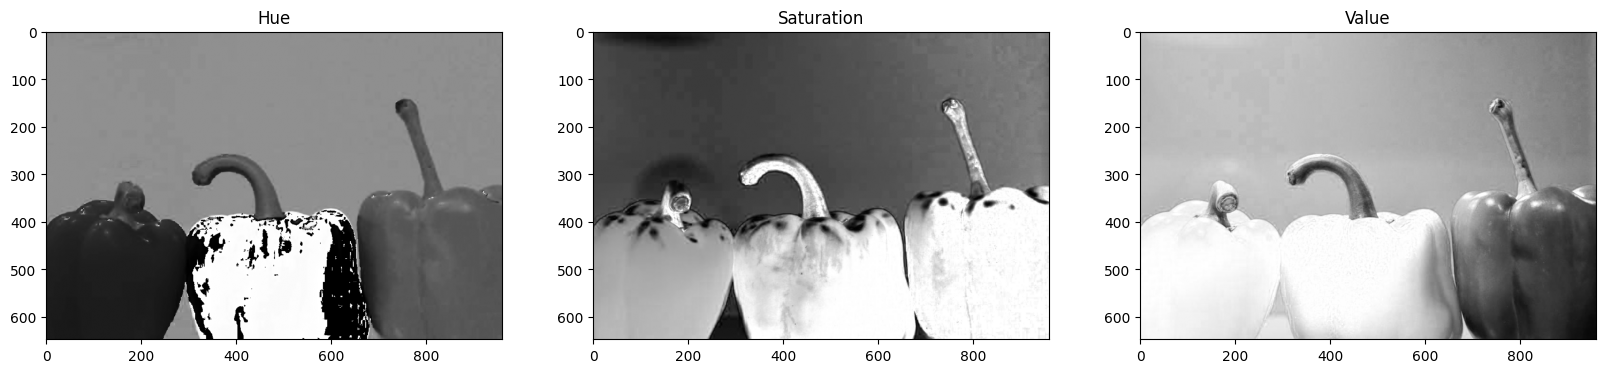

In [5]:
plt.figure(figsize=(20,15))
plt.subplot(131);plt.imshow(hsvImage[:,:,0], cmap="gray");plt.title("Hue")
plt.subplot(132);plt.imshow(hsvImage[:,:,1], cmap="gray");plt.title("Saturation")
plt.subplot(133);plt.imshow(hsvImage[:,:,2], cmap="gray");plt.title("Value")

#### Understanding HSV color space with few tests

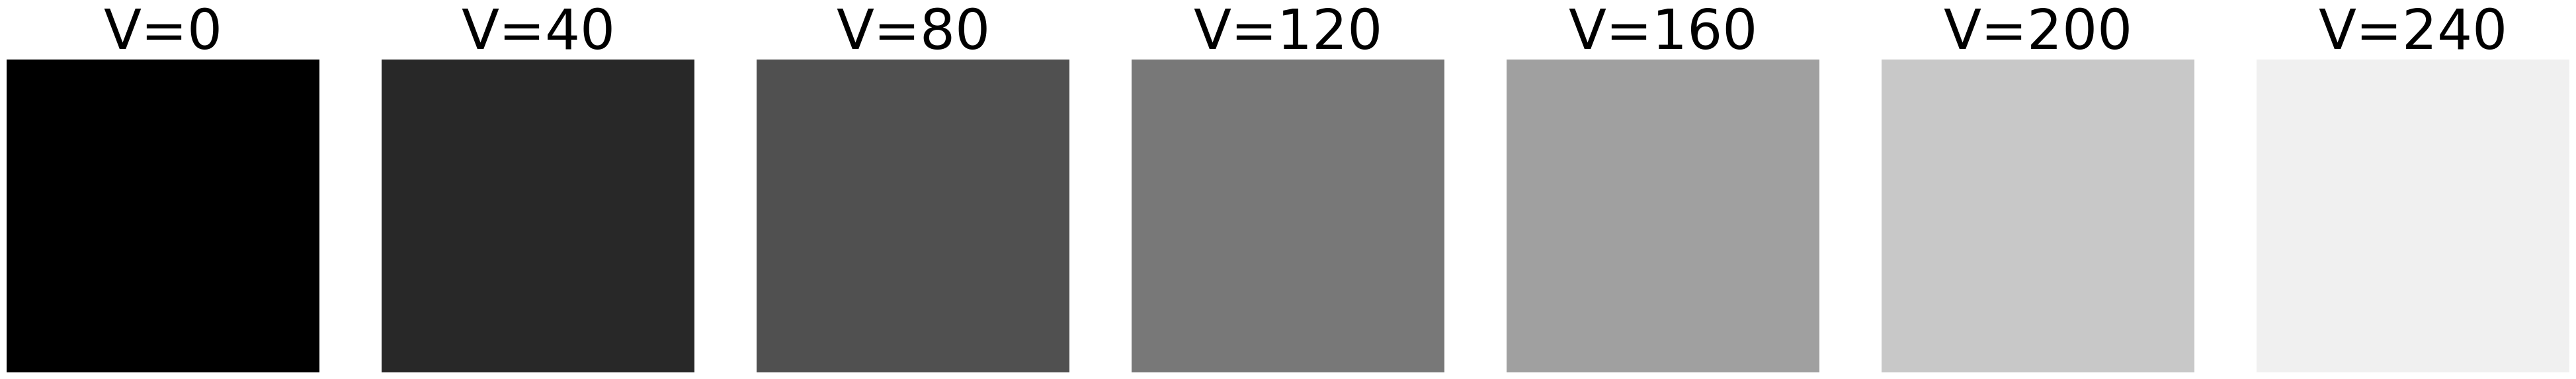

In [10]:
plt.figure(figsize=(50,50))

for i in range(0,7):
    imhsv = np.zeros((50,50,3), dtype=np.uint8)
    
    # Setting Hue=0, Saturation=0, Value = i*40
    v = i*40
    imhsv[:,:,:] = (0,0,v)

    # Convert HSV to RGB
    imrgb = cv2.cvtColor(imhsv, cv2.COLOR_HSV2RGB)

    # Display image
    ax = plt.subplot(1, 7, i+1)
    plt.imshow(imrgb)
    plt.axis('off')
    ax.set_title('V='+str(v), fontdict={'fontsize': 60, 'fontweight': 'medium'})

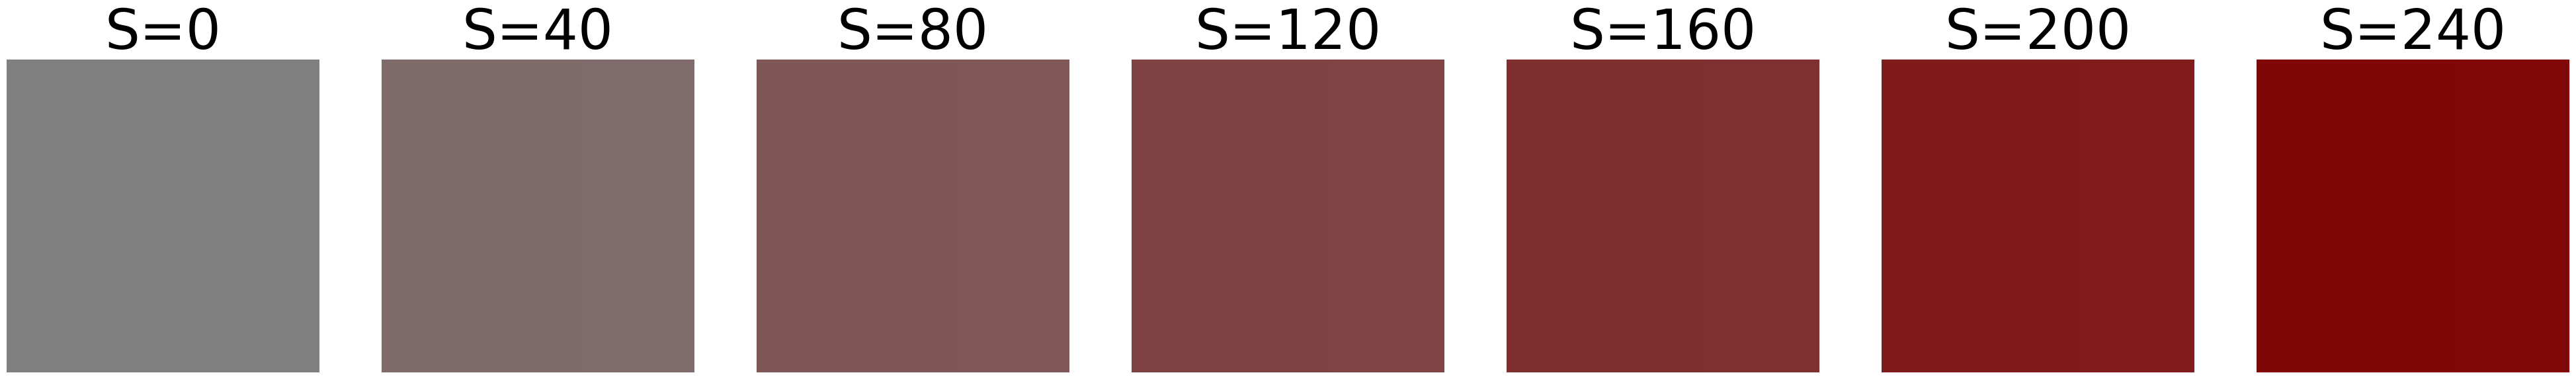

In [11]:
plt.figure(figsize=(50,50))

for i in range(0,7):
    imhsv = np.zeros((50,50,3), dtype=np.uint8)
    
    # Setting Hue = 0, Saturation = i*40, Value = 128
    s = i*40
    imhsv[:,:,:] = (0,s,128)

    # Convert HSV to RGB
    imrgb = cv2.cvtColor(imhsv, cv2.COLOR_HSV2RGB)

    # Display image
    ax = plt.subplot(1, 7, i+1)
    plt.imshow(imrgb)
    plt.axis('off')
    ax.set_title('S='+str(s), fontdict={'fontsize': 60, 'fontweight': 'medium'})

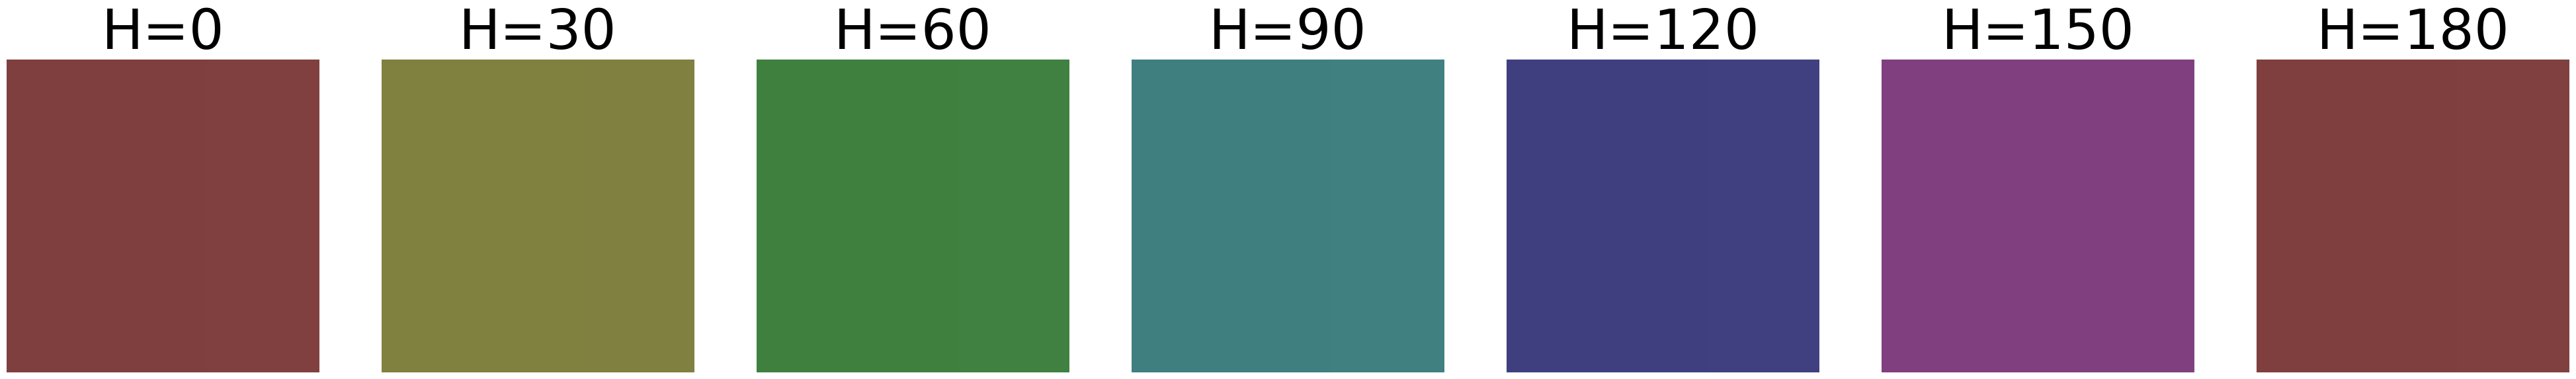

In [13]:
plt.figure(figsize=(50,50))

for i in range(0,7):
    imhsv = np.zeros((50,50,3), dtype=np.uint8)
    
    # Setting Hue = i*30, Saturation = 128, Value = 128
    h = i*30
    imhsv[:,:,:] = (h,128,128)

    # Convert HSV to RGB
    imrgb = cv2.cvtColor(imhsv, cv2.COLOR_HSV2RGB)

    # Display image
    ax = plt.subplot(1, 7, i+1)
    plt.imshow(imrgb)
    plt.axis('off')
    ax.set_title('H='+str(h), fontdict={'fontsize': 60, 'fontweight': 'medium'})

#### The YCrCb Color Space

- Y {Luma} (derived from RGB) encodes Brightness
- Cr = R - Y (how far is the red component from the Luma, also known as Red Difference)
- Cb = B - Y (how far is the blue component from the Luma, also known as Blue Difference)

Text(0.5, 1.0, 'Cb Channel')

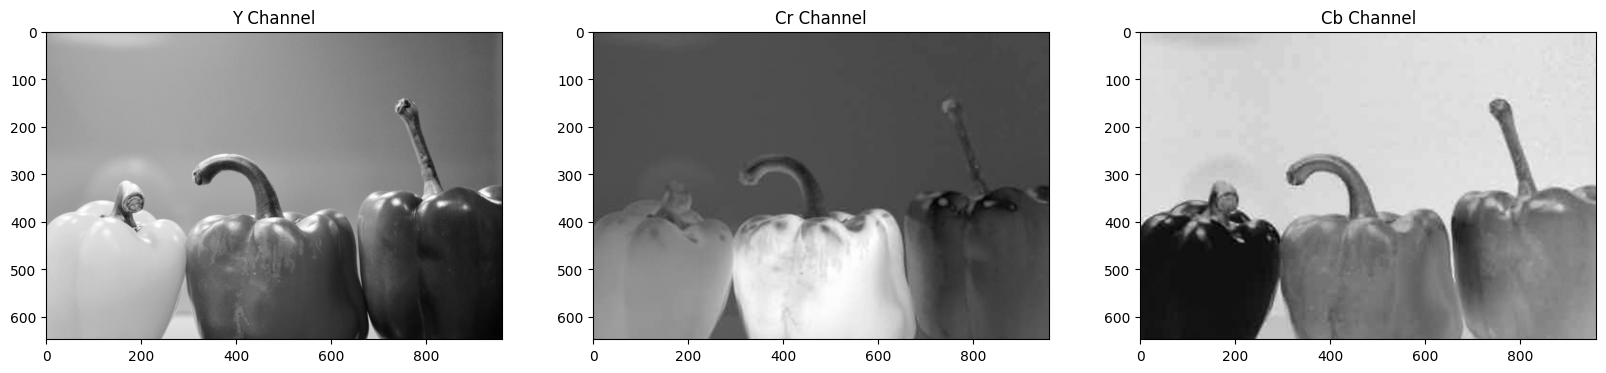

In [14]:
# Read the Image
bgr = cv2.imread('data/images/capsicum.jpg', cv2.IMREAD_COLOR)
# Convert from BGR to YCrCb
ycbImage = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)
# Display the images
plt.figure(figsize=(20,15))
plt.subplot(131);plt.imshow(ycbImage[:,:,0], cmap="gray");plt.title("Y Channel")
plt.subplot(132);plt.imshow(ycbImage[:,:,1], cmap="gray");plt.title("Cr Channel")
plt.subplot(133);plt.imshow(ycbImage[:,:,2], cmap="gray");plt.title("Cb Channel")


#### The Lab color space

- Lightness (/Brightness/Luminance)
- A (a color component ranging from Green to Magenta)
- B (a color component ranging from Blue to Yellow)

In [15]:
labImage = cv2.cvtColor(bgr, cv2.COLOR_BGR2Lab)

Text(0.5, 1.0, 'B Channel')

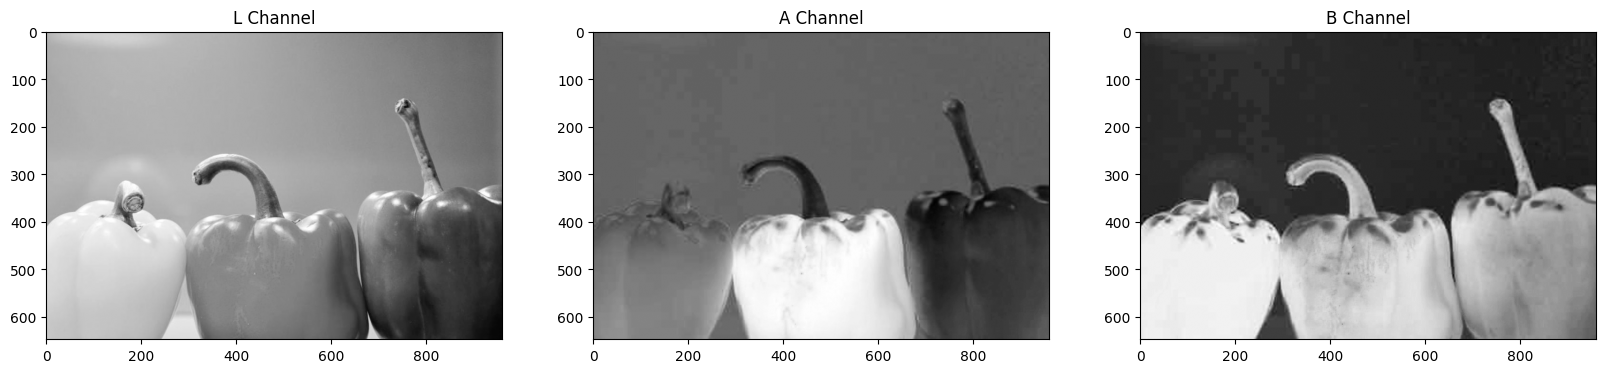

In [16]:
plt.figure(figsize=(20,15))
plt.subplot(131);plt.imshow(labImage[:,:,0], cmap="gray");plt.title("L Channel")
plt.subplot(132);plt.imshow(labImage[:,:,1], cmap="gray");plt.title("A Channel")
plt.subplot(133);plt.imshow(labImage[:,:,2], cmap="gray");plt.title("B Channel")

## CONCLUSION

- In RGB color space, all 3 channels carry info on both color(Chrominance) and brightness(Luminance). `This separation is present in other color spaces`

- In HSV color space, coordinates are cylindrical. Hue has a range of 0-180 degree, Saturation can be imagined as Z-axis (saturation moves from lighter color to stronger color.) and Value as Y-axis (Less value means near black, more value means near white)


#### Application - Finding Dominant color in an image

(np.float64(-0.5), np.float64(384.5), np.float64(384.5), np.float64(-0.5))

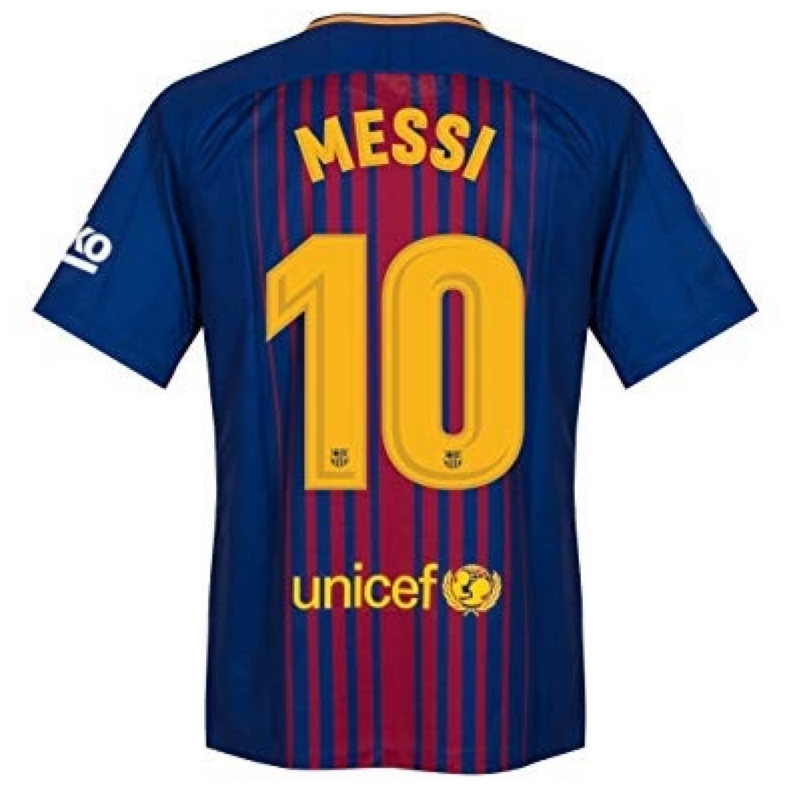

In [21]:
image = cv2.imread('data/images/jersey.jpg')

plt.figure(figsize=(20,10))
plt.imshow(image[:,:,::-1])
plt.axis('off')

In [22]:
# convert to hsv
hsvImage = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(hsvImage)
h, h.shape

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(385, 385), dtype=uint8),
 (385, 385))

In [23]:
flattened_h = h[s>10].flatten()
flattened_h,flattened_h.shape

(array([26, 23, 30, ..., 92, 45, 39], shape=(85188,), dtype=uint8), (85188,))

Text(0.5, 1.0, 'Histogram')

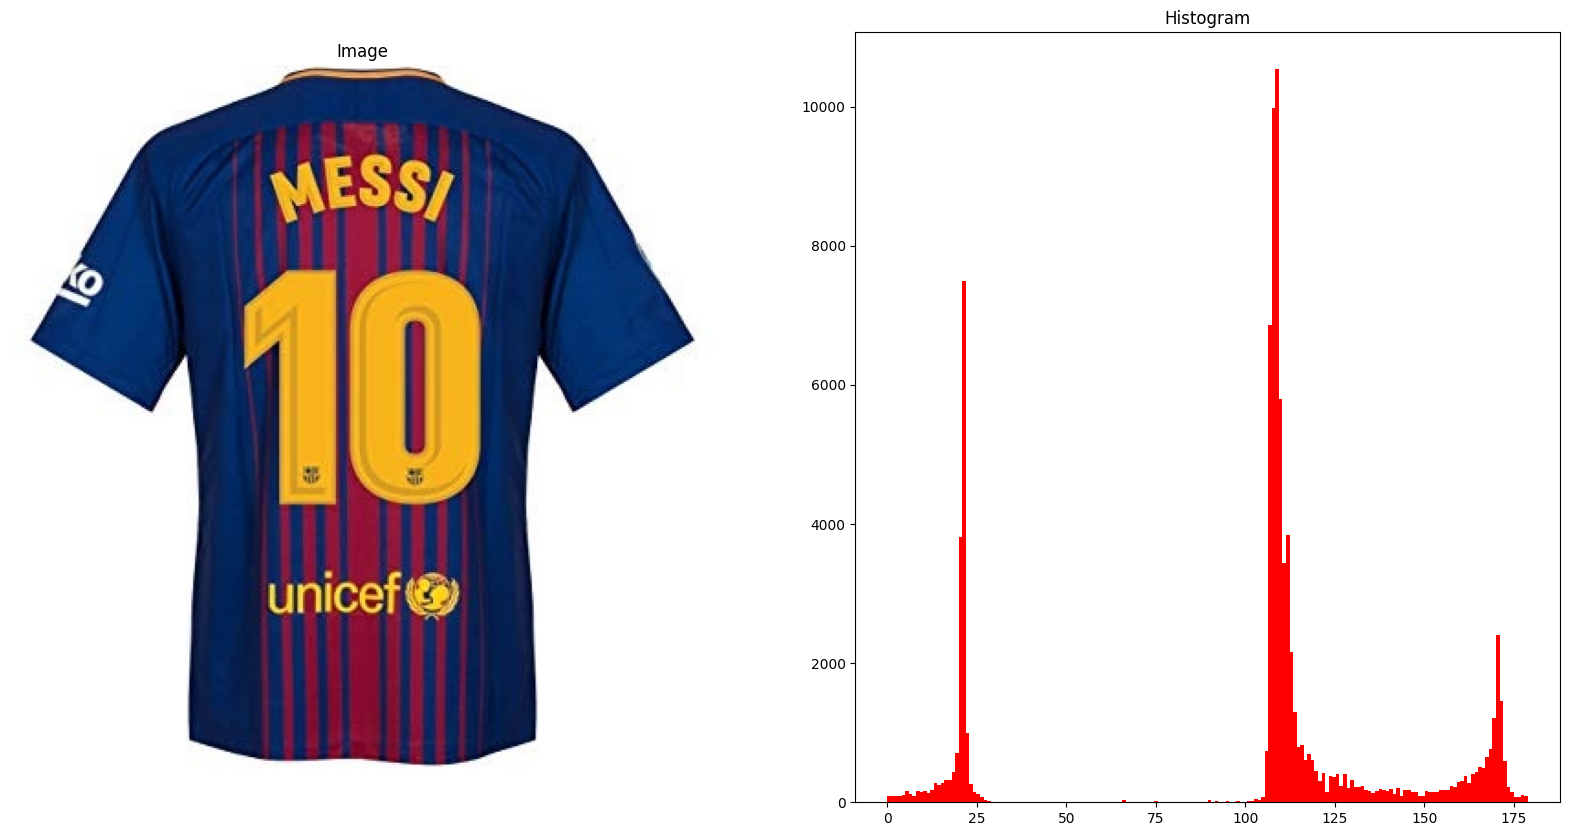

In [ ]:
plt.figure(figsize=[20,10])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Image");plt.axis('off')
plt.subplot(122);plt.hist(flattened_h, bins=180, color='r');plt.title("Histogram")

# x-axis is the entire hue range (0-180)
# if you go and check above for colors, you'll know that 
# first peak is yellow, second is blue, and third is red

#### Application - Desaturation filter

In [35]:
img = cv2.imread('data/images/girl.jpg')

In [45]:
saturationScale = 0.52 # 1%

hsvImg = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

hsvImg = np.float32(hsvImg) # since we'll multiply saturationScale with it

h,s,v = cv2.split(hsvImg)

In [46]:
s = np.clip(s * saturationScale, 0, 255)

hsvImg = np.uint8(cv2.merge([h,s,v]))
saturatedImg = cv2.cvtColor(hsvImg, cv2.COLOR_HSV2BGR)

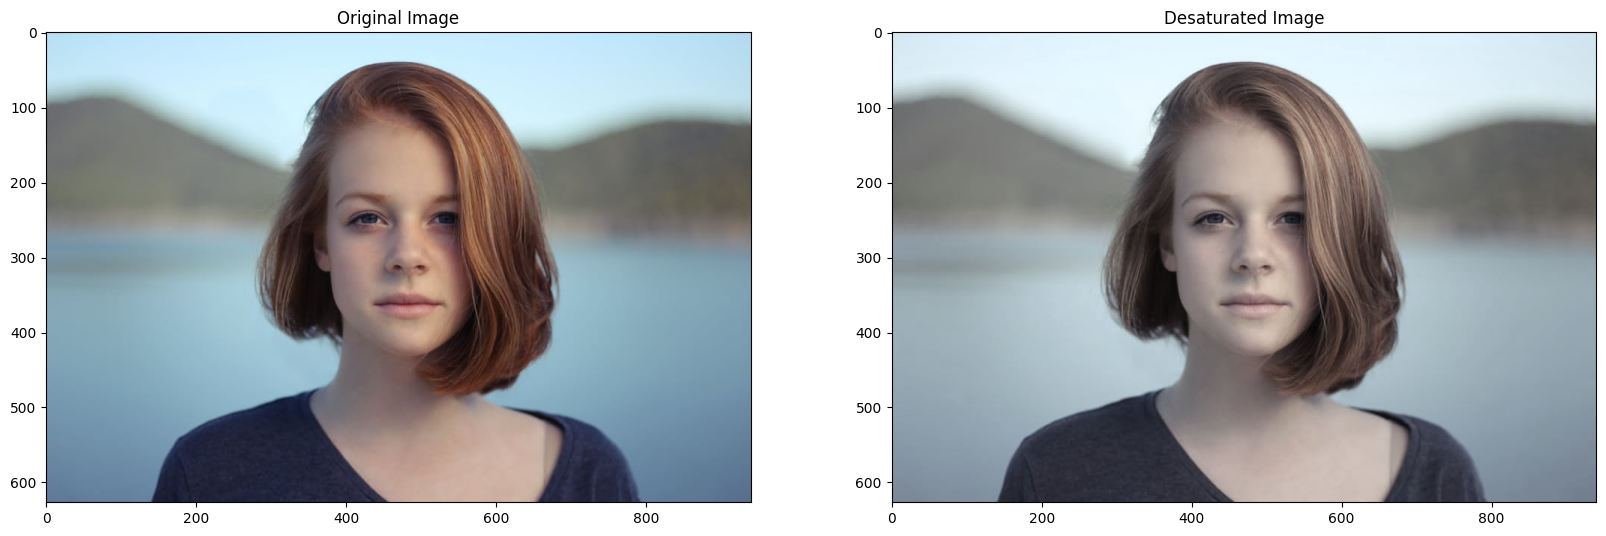

In [47]:
plt.figure(figsize=[20,10])
plt.subplot(121);plt.imshow(img[...,::-1]);plt.title('Original Image')
plt.subplot(122);plt.imshow(saturatedImg[...,::-1]);plt.title('Desaturated Image');

#### cvtColor Assignment

- Part 1

Text(0.5, 1.0, 'Difference')

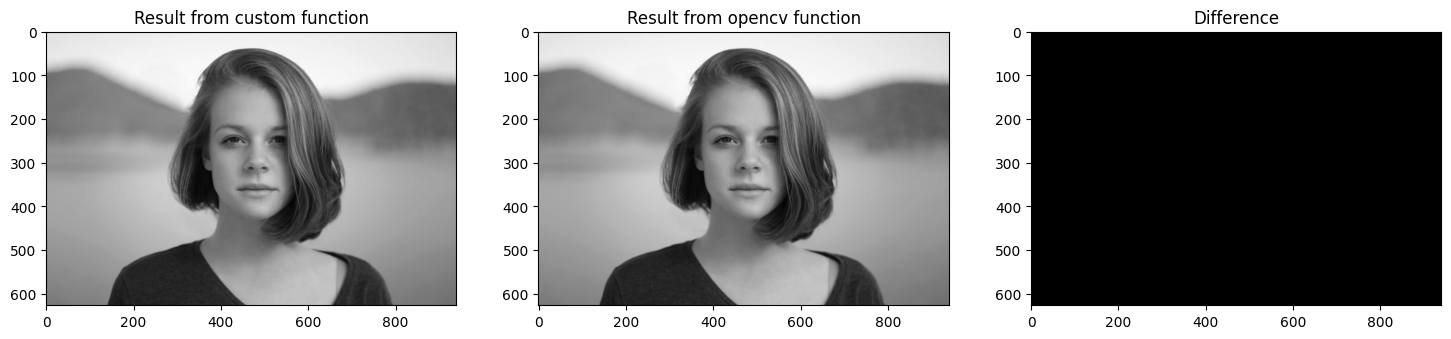

In [49]:
def convertBGRtoGray(image):
    ###
    image = np.float32(image)
    b,g,r = image[:,:,0],image[:,:,1],image[:,:,2]
    gray = 0.114 * b + 0.587 * g + 0.299 * r
    return np.uint8(np.round(np.clip(gray,0,255)))

gray = convertBGRtoGray(img)
gray_cv = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(18,12))
plt.subplot(131);plt.imshow(gray, cmap="gray");plt.title("Result from custom function")
plt.subplot(132);plt.imshow(gray_cv, cmap="gray");plt.title("Result from opencv function")
plt.subplot(133);plt.imshow(np.abs(gray - gray_cv), cmap="gray");plt.title("Difference")

- Part 2

Text(0.5, 1.0, 'Difference')

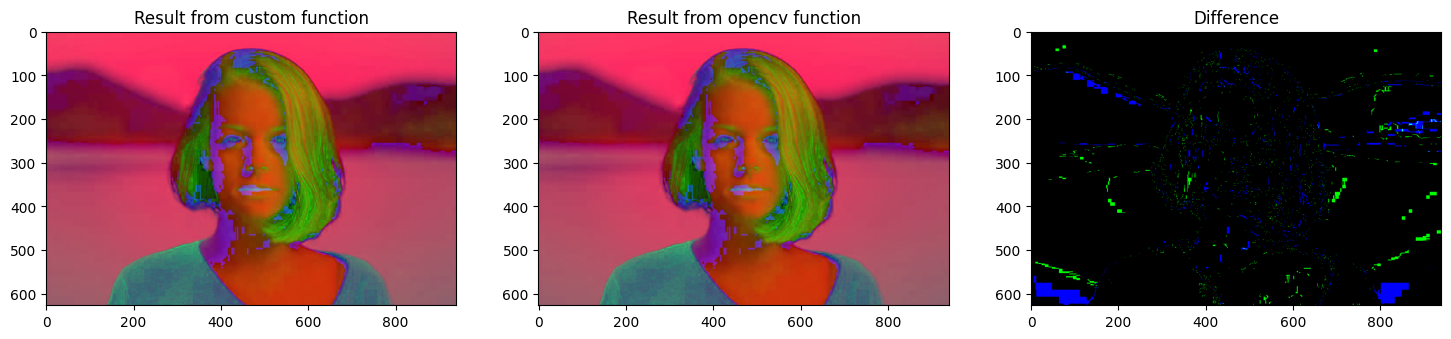

In [58]:
def convertRGBtoHSV_standard(image):
    image = np.float32(image) / 255.0

    b, g, r = image[:,:,0], image[:,:,1], image[:,:,2]

    cmax = np.maximum(np.maximum(r, g),b)
    cmin = np.minimum(np.minimum(r, g),b)
    delta = cmax - cmin

    # Value
    v = cmax

    # Saturation
    s = np.zeros_like(v)
    nonzero = v != 0
    s[nonzero] = (delta[nonzero] / v[nonzero])

    # Hue
    h = np.zeros_like(v)
    mask = delta != 0

    r_mask = (v == r) & mask
    h[r_mask] = 60 * (g[r_mask] - b[r_mask]) / delta[r_mask]

    g_mask = (v == g) & mask
    h[g_mask] = 120 + 60 * (b[g_mask] - r[g_mask]) / delta[g_mask]

    b_mask = (v == b) & mask
    h[b_mask] = 240 + 60 * (r[b_mask] - g[b_mask]) / delta[b_mask]

    h[h < 0] += 360

    h = np.round(h / 2)
    s = np.round(s * 255)
    v = np.round(v * 255)
    
    h = np.uint8(h)
    s = np.uint8(s)
    v = np.uint8(v)

    hsv = np.stack([h, s, v], axis=-1)

    return hsv


hsv = convertRGBtoHSV_standard(img)
hsv_cv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
plt.figure(figsize=(18,12))
plt.subplot(131);plt.imshow(hsv[...,::-1], cmap="gray");plt.title("Result from custom function")
plt.subplot(132);plt.imshow(hsv_cv[...,::-1], cmap="gray");plt.title("Result from opencv function")
plt.subplot(133);plt.imshow(np.abs(hsv - hsv_cv)[...,::-1], cmap="gray");plt.title("Difference")